---
tags: [algorithm, optimization, variational]
---

# QAOA for Graph Partitioning

This tutorial demonstrates how to solve the **graph partitioning problem**
using the Quantum Approximate Optimization Algorithm (QAOA) with Qamomile.

The workflow is:

```
JijModeling problem → problem.eval() → QAOAConverter → transpile → sample → decode
```

1. Formulate the problem with [JijModeling](https://jij-inc-jijmodeling-tutorials-en.readthedocs-hosted.com/en/latest/introduction.html).
2. Create an instance with concrete data.
3. Use `QAOAConverter` to build the QAOA circuit and Hamiltonian.
4. Optimize the variational parameters with a classical optimizer.
5. Sample the optimized circuit and decode the results.

In [1]:
# Install the latest Qamomile through pip!
# !pip install qamomile

## Problem Formulation

Given an undirected graph $G = (V, E)$, the goal is to partition the vertices
into two groups of equal size while minimizing the number of edges between
the two groups.

**Objective:**

$$
\min \sum_{(u,v) \in E} \bigl[x_u(1 - x_v) + x_v(1 - x_u)\bigr]
$$

**Constraint:**

$$
\sum_{u \in V} x_u = \frac{|V|}{2}
$$

where $x_u \in \{0, 1\}$ indicates which partition vertex $u$ belongs to.

## Define the Problem with JijModeling

In [2]:
import jijmodeling as jm

problem = jm.Problem("Graph Partitioning")


@problem.update
def _(problem: jm.DecoratedProblem):
    V = problem.Dim()
    E = problem.Natural(ndim=2)  # edge list: [[u1,v1], [u2,v2], ...]
    x = problem.BinaryVar(shape=(V,))

    # Objective: minimize edges cut between partitions
    problem += (
        E.rows().map(lambda e: x[e[0]] * (1 - x[e[1]]) + x[e[1]] * (1 - x[e[0]])).sum()
    )

    # Constraint: equal partition sizes
    problem += problem.Constraint("equal_partition", x.sum() == V / 2)


problem

Problem(name="Graph Partitioning", sense=MINIMIZE, objective=sum(E.rows().map(lambda (e: Array[:; natural]): x[e[0]] * (1 - x[e[1]]) + x[e[1]] * (1 - x[e[0]]))), constraints={equal_partition: [Constraint(name="equal_partition", sense=EQUAL, left=sum(x), right=V / 2, shape=Scalar(Float)),],})

## Graph Instance

We use a fixed 8-node graph with 16 edges for reproducibility.

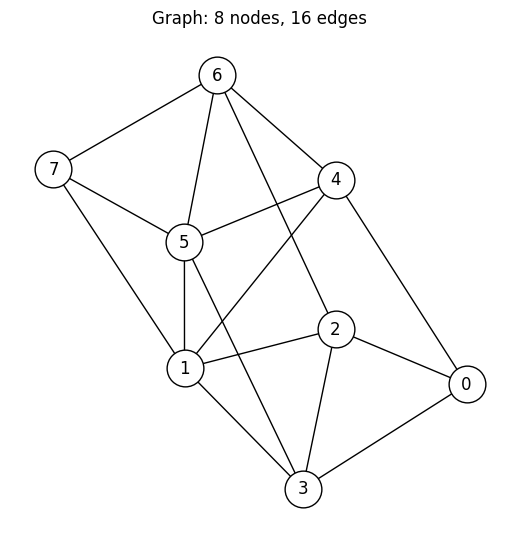

In [3]:
import matplotlib.pyplot as plt
import networkx as nx

num_nodes = 8
edge_list = [
    [0, 2],
    [0, 3],
    [0, 4],
    [1, 2],
    [1, 3],
    [1, 4],
    [1, 5],
    [1, 7],
    [2, 3],
    [2, 6],
    [3, 5],
    [4, 5],
    [4, 6],
    [5, 6],
    [5, 7],
    [6, 7],
]

G = nx.Graph()
G.add_nodes_from(range(num_nodes))
G.add_edges_from(edge_list)

pos = nx.spring_layout(G, seed=1)
plt.figure(figsize=(5, 5))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="white",
    node_size=700,
    edgecolors="black",
)
plt.title(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
plt.show()

## Create the Instance

We extract the edge list from the graph and evaluate the JijModeling
problem with the concrete data.

In [4]:
instance_data = {"V": num_nodes, "E": edge_list}
instance = problem.eval(instance_data)

## Set Up the QAOAConverter

`QAOAConverter` takes an OMMX instance and internally:
1. Converts the problem to a QUBO (Quadratic Unconstrained Binary Optimization) form.
2. Transforms from BINARY variables to SPIN variables.
3. Builds the cost Hamiltonian as a sum of Pauli-Z operators.

Because the original problem has a constraint, the QUBO formulation folds it
into the objective as a **penalty term**. This means the energy values from
the decoded samples are **not** the original objective (number of cut edges)
— they include the penalty. We will need to check feasibility and compute
the true objective separately.

In [5]:
from qamomile.optimization.qaoa import QAOAConverter

converter = QAOAConverter(instance)
converter.spin_model = converter.spin_model.normalize_by_abs_max()
hamiltonian = converter.get_cost_hamiltonian()
print(hamiltonian)

Hamiltonian((Z0, Z1): 1.0, (Z0, Z5): 1.0, (Z0, Z6): 1.0, (Z0, Z7): 1.0, (Z1, Z6): 1.0, (Z2, Z4): 1.0, (Z2, Z5): 1.0, (Z2, Z7): 1.0, (Z3, Z4): 1.0, (Z3, Z6): 1.0, (Z3, Z7): 1.0, (Z4, Z7): 1.0)


## Transpile to an Executable Circuit

`converter.transpile()` builds a QAOA ansatz circuit with `p` layers and
compiles it into an `ExecutableProgram`. The variational parameters
`gammas` (cost layer) and `betas` (mixer layer) remain as runtime parameters.

In [6]:
from qamomile.qiskit import QiskitTranspiler

transpiler = QiskitTranspiler()
p = 5  # number of QAOA layers
executable = converter.transpile(transpiler, p=p)

## Visualize the QAOA Circuit

`QAOAConverter._transpile_quadratic()` internally builds the sampling
qkernel below and feeds it to the transpiler. For visualization we
restate that qkernel *verbatim*, then trace it through the early
pipeline (`Transpiler.to_block` to lower it into an IR Block,
`Transpiler.inline` to expand the sub-qkernel calls) before handing
the resulting Block to `MatplotlibDrawer.draw`. This renders exactly
the Block structure the converter works with internally, with `p=2`
for readability.

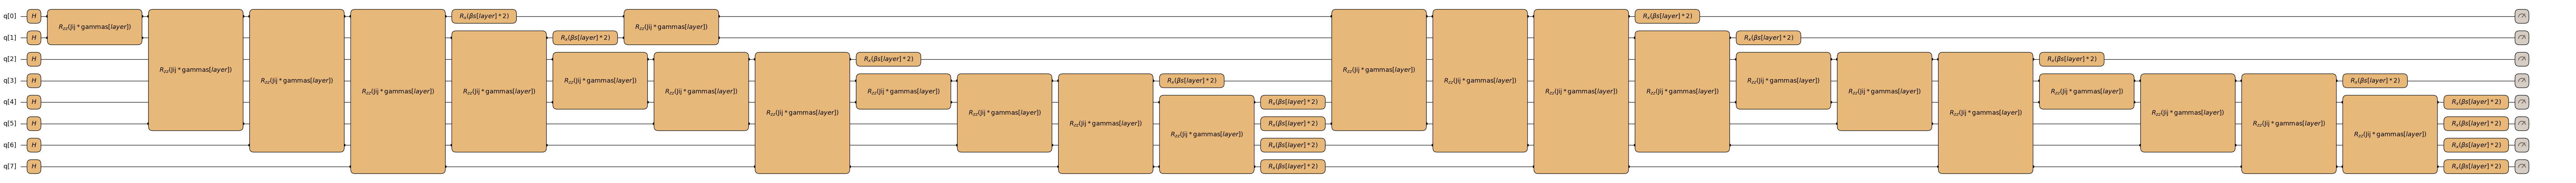

In [7]:
import qamomile.circuit as qmc
from qamomile.circuit.algorithm.qaoa import qaoa_state
from qamomile.circuit.visualization import MatplotlibDrawer


@qmc.qkernel
def qaoa_sampling(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
    n: qmc.UInt,
) -> qmc.Vector[qmc.Bit]:
    q = qaoa_state(p=p, quad=quad, linear=linear, n=n, gammas=gammas, betas=betas)
    return qmc.measure(q)


block = transpiler.to_block(
    qaoa_sampling,
    bindings={
        "linear": converter.spin_model.linear,
        "quad": converter.spin_model.quad,
        "n": converter.spin_model.num_bits,
        "p": 2,
    },
    parameters=["gammas", "betas"],
)
block = transpiler.inline(block)
# `fold_loops=False` unrolls every loop (`for layer`,
# `for (i,j),Jij in quad`, and the per-qubit range loops) so each gate
# is rendered explicitly. `linear` is the empty dict `{}` for graph
# partition (no linear Ising terms), so its ForItems loop has zero
# iterations and is rendered as nothing rather than as a folded box.
MatplotlibDrawer(block).draw(fold_loops=False)

### Inspecting the Building Blocks

Inside `qaoa_sampling` we call `qaoa_state`, and `qaoa_state` itself
is the composition of three smaller qkernels:

- `superposition_vector(n)` — applies `H` to every qubit, preparing
  the initial state $|+\rangle^{\otimes n}$.
- `ising_cost(quad, linear, q, gamma)` — the cost layer: one `RZZ`
  per quadratic entry in `quad` and one `RZ` per linear entry in
  `linear`. The graph-partition spin model has no linear terms
  (`linear={}`), so only `RZZ` gates appear.
- `x_mixer(q, beta)` — the mixer layer: applies `RX(2\beta)` to every
  qubit.

`qaoa_layers(p, ...)` is just the alternation of `ising_cost` and
`x_mixer`, repeated `p` times. Below we render each piece on its own.

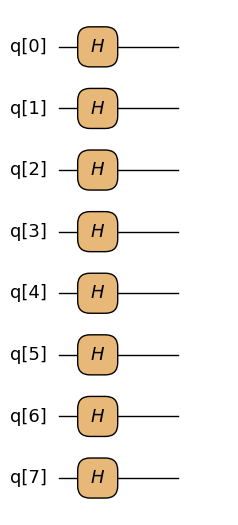

In [8]:
from qamomile.circuit.algorithm.basic import superposition_vector
from qamomile.circuit.algorithm.qaoa import ising_cost, x_mixer

superposition_vector.draw(n=converter.spin_model.num_bits, fold_loops=False)

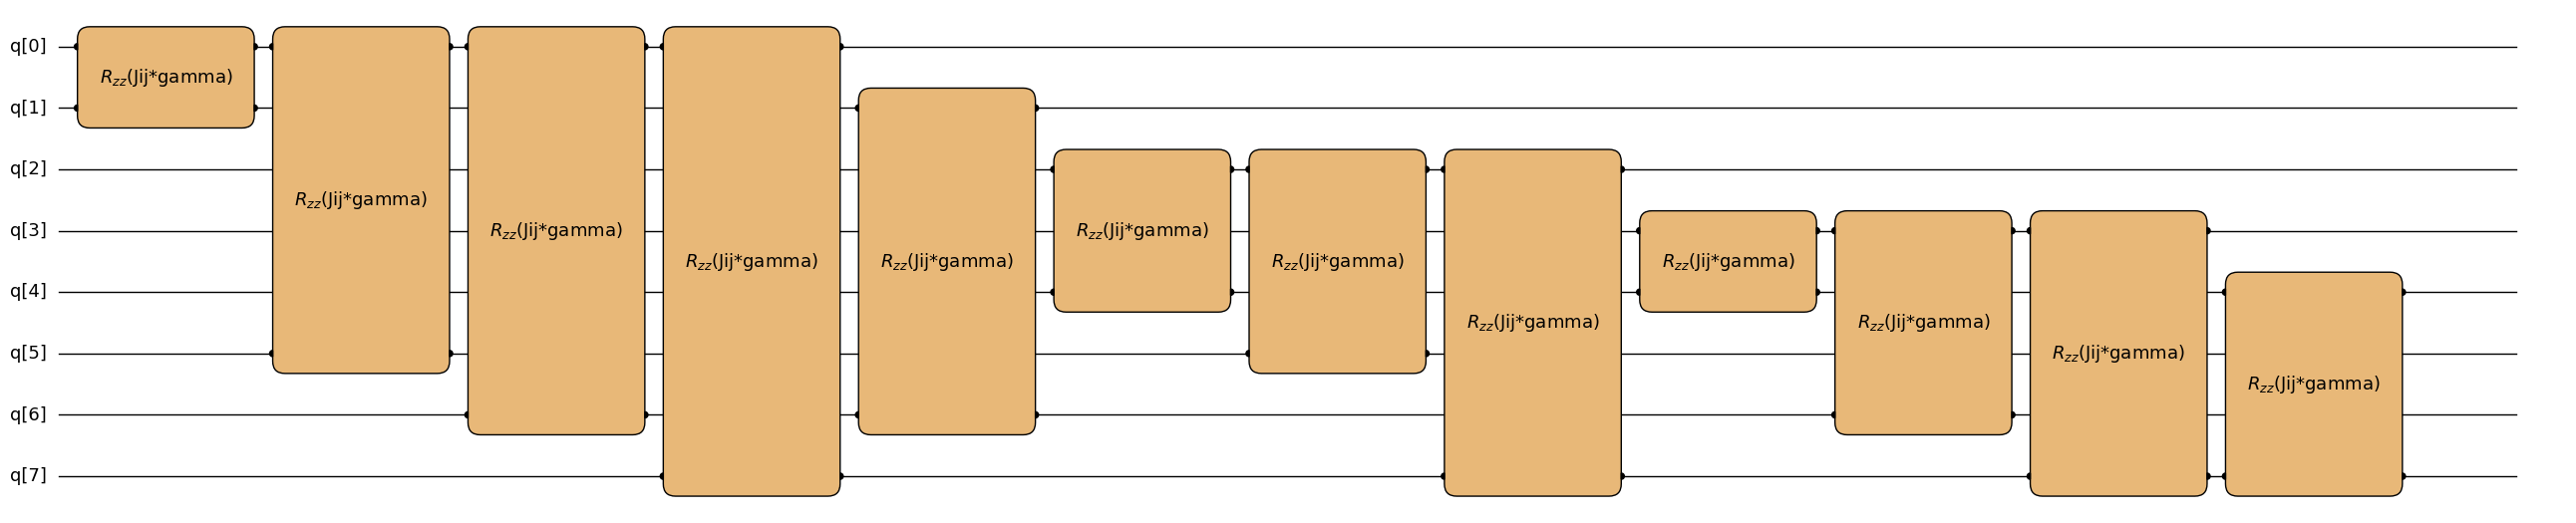

In [9]:
ising_cost.draw(
    q=converter.spin_model.num_bits,
    quad=converter.spin_model.quad,
    linear=converter.spin_model.linear,
    fold_loops=False,
)

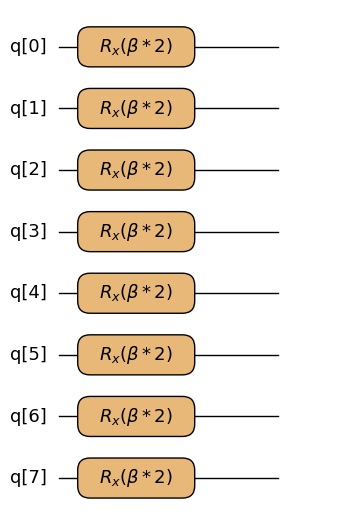

In [10]:
x_mixer.draw(q=converter.spin_model.num_bits, fold_loops=False)

## Optimize the QAOA Parameters

We use `executable.sample()` to evaluate the cost at each iteration of the
classical optimizer. The optimizer explores different `gammas` and `betas`
to minimize the mean energy of the sampled bitstrings.

In [11]:
import os

import numpy as np
from qiskit_aer import AerSimulator
from scipy.optimize import minimize

# Seed the simulator so re-executing the notebook reproduces the same
# COBYLA trajectory and final sampling distribution. Without a seed,
# every shot draws fresh randomness, COBYLA sees a noisy cost surface,
# and each notebook run converges to a different (but equivalent) local
# optimum.
executor = transpiler.executor(
    backend=AerSimulator(seed_simulator=901, max_parallel_threads=1)
)
docs_test_mode = os.environ.get("QAMOMILE_DOCS_TEST") == "1"
sample_shots = 256 if docs_test_mode else 2048
maxiter = 25 if docs_test_mode else 1000

rng = np.random.default_rng(900)
initial_params = rng.uniform(0, np.pi, 2 * p)

cost_history = []


def cost_fn(params):
    gammas = list(params[:p])
    betas = list(params[p:])
    job = executable.sample(
        executor,
        shots=sample_shots,
        bindings={"gammas": gammas, "betas": betas},
    )
    result = job.result()
    # decode_to_binary_sampleset returns the QUBO-domain BinarySampleSet
    # whose `energy` is the penalized objective — what COBYLA needs to
    # see infeasibility costs. The polymorphic decode() returns an
    # ommx.v1.SampleSet whose `objective` is the un-penalized true
    # objective; using it here would let the optimizer settle on
    # infeasible all-zero / all-one bitstrings.
    decoded = converter.decode_to_binary_sampleset(result)
    energy = decoded.energy_mean()
    cost_history.append(energy)
    return energy


res = minimize(
    cost_fn,
    initial_params,
    method="COBYLA",
    options={"maxiter": maxiter},
)

print(f"Optimized cost: {res.fun:.3f}")
print(f"Optimal params: {[round(v, 4) for v in res.x]}")
print(f"Function evaluations: {res.nfev}")

Optimized cost: 14.235
Optimal params: [np.float64(0.5042), np.float64(0.9744), np.float64(3.1558), np.float64(0.7789), np.float64(2.1748), np.float64(1.1239), np.float64(3.6516), np.float64(1.5606), np.float64(1.5563), np.float64(0.7607)]
Function evaluations: 117


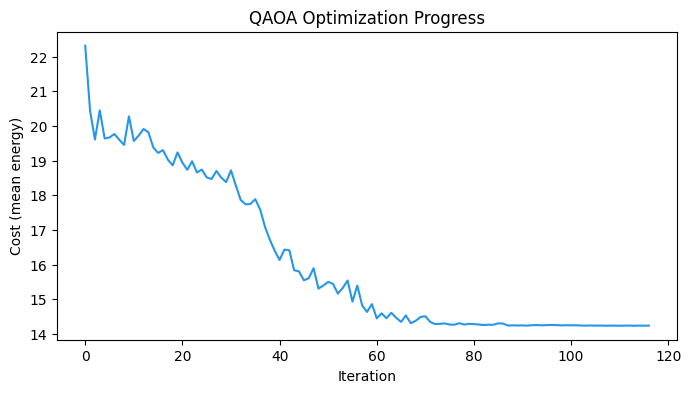

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(cost_history, color="#2696EB")
plt.xlabel("Iteration")
plt.ylabel("Cost (mean energy)")
plt.title("QAOA Optimization Progress")
plt.show()

## Sample with Optimized Parameters

With the optimized parameters, we sample the circuit to collect
candidate solutions as bitstrings.

In [13]:
gammas_opt = list(res.x[:p])
betas_opt = list(res.x[p:])

sample_result = executable.sample(
    executor,
    shots=1000,
    bindings={"gammas": gammas_opt, "betas": betas_opt},
).result()

# `decode()` on an OMMX-backed converter returns an `ommx.v1.SampleSet`
# evaluated against the *original* (un-penalized) instance, so
# feasibility, the true objective, and per-constraint diagnostics are
# available through OMMX's own API — no hand-rolled feasibility or
# objective helper is needed.
sample_set = converter.decode(sample_result)

## Analyze the Results

### Feasibility Check

QAOA samples are **candidate solutions** — they are not guaranteed to
satisfy the original constraints. The constraint $\sum x_u = |V|/2$ was
folded into the QUBO as a penalty, so infeasible bitstrings can still
appear in the output.

`SampleSet.summary` is a DataFrame with one row per shot whose
`feasible` column already encodes feasibility against the *original*
constraints, so we can read the feasible-shot count straight off it.

In [14]:
summary = sample_set.summary
total_feasible = int(summary["feasible"].sum())
total_samples = len(summary)

print(
    f"Feasible samples: {total_feasible} / {total_samples} "
    f"({100 * total_feasible / total_samples:.1f}%)"
)

Feasible samples: 538 / 1000 (53.8%)


### Best Feasible Solution

`SampleSet.best_feasible` returns the feasible sample with the
best (here: smallest) objective. Because the converter was built from
an OMMX `Instance`, the reported objective is the *original*
un-penalized one — i.e. the number of cut edges itself — and the
decision-variable values come back keyed by the original variable
IDs in `decision_variables_df`.

In [15]:
if total_feasible > 0:
    best = sample_set.best_feasible
    best_obj = int(round(best.objective))
    best_sample = {
        i: int(round(best.decision_variables_df.loc[i, "value"]))
        for i in range(num_nodes)
    }
    print(f"Best feasible solution: {best_sample}")
    print(f"Cut edges:             {best_obj}")
else:
    print("No feasible solution found. Try increasing p or maxiter.")
    best_sample = None
    best_obj = None

Best feasible solution: {0: 1, 1: 1, 2: 1, 3: 1, 4: 0, 5: 0, 6: 0, 7: 0}
Cut edges:             6


### Objective Value Distribution

We plot the distribution of the true objective value (cut edges)
for feasible samples only. `summary` already has the original
objective per shot, so a `value_counts()` on the feasible slice
gives the histogram directly.

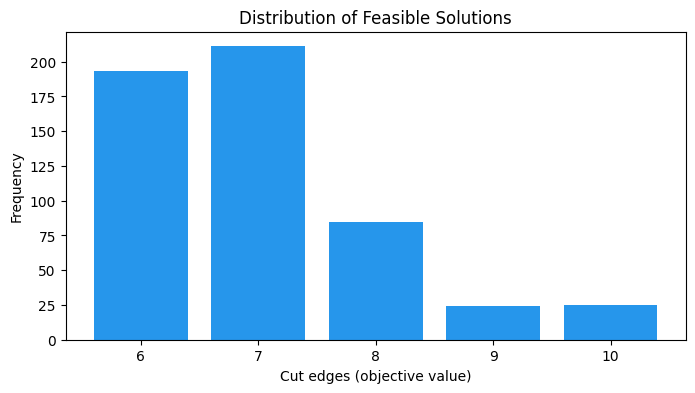

In [16]:
if total_feasible > 0:
    feasible_objectives = (
        summary.loc[summary["feasible"], "objective"].round().astype(int)
    )
    obj_counts = feasible_objectives.value_counts().sort_index()

    plt.figure(figsize=(8, 4))
    plt.bar([str(o) for o in obj_counts.index], obj_counts.values, color="#2696EB")
    plt.xlabel("Cut edges (objective value)")
    plt.ylabel("Frequency")
    plt.title("Distribution of Feasible Solutions")
    plt.show()

### Visualize the Best Partition

We color the graph nodes according to the best feasible partition
found by QAOA.

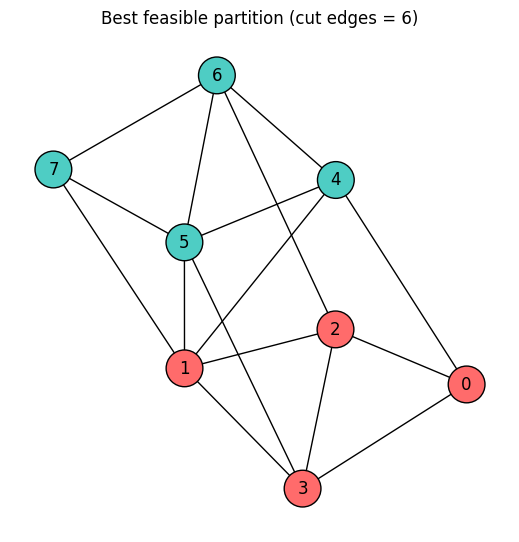

In [17]:
if best_sample is not None:
    color_map = [
        "#FF6B6B" if best_sample.get(i, 0) == 1 else "#4ECDC4" for i in range(num_nodes)
    ]

    plt.figure(figsize=(5, 5))
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color=color_map,
        node_size=700,
        edgecolors="black",
    )
    plt.title(f"Best feasible partition (cut edges = {best_obj})")
    plt.show()